--- Diagnosing and Merging 39 ORAS5 Files ---

     FINAL TIMELINE NAN DETAILED INSPECTION REPORT        
🚨 Total missing months found in anomaly timeline: 4 months
         Date  Year  Month  ATL3_SSTA
15 1988-10-01  1988     10        NaN
16 1988-11-01  1988     11        NaN
27 1989-10-01  1989     10        NaN
28 1989-11-01  1989     11        NaN

--- Cleaned ORAS5 Monthly Anomaly Sample ---
         Date  Year  Month       ATL3  ATL3_SSTA
0  1982-08-01  1982      8  23.388607  -1.152315
1  1983-09-01  1983      9  24.664171  -0.220884
2  1984-09-01  1984      9  25.580713   0.695658
3  1985-08-01  1985      8  24.531101  -0.009821
4  1986-04-01  1986      4  28.919487   0.408789
5  1987-05-01  1987      5  27.676168   1.002241
6  1988-01-01  1988      1  27.916077   0.302467
7  1988-02-01  1988      2  28.429495   0.110655
8  1988-03-01  1988      3  29.118994   0.601032
9  1988-04-01  1988      4  29.328135   0.817436
10 1988-05-01  1988      5  28.604908   1.930981
11 1988-06-

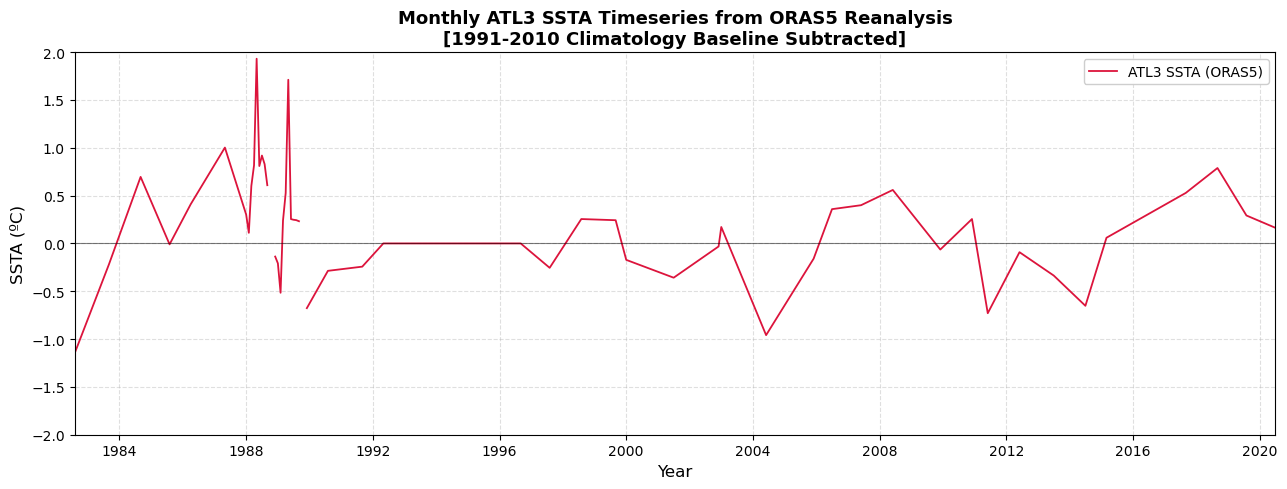

In [19]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import glob
import os

# 1. Define directory path
base_dir = "/Users/yongyub.kim/kimyy/Research/Postdoc/10_GFI_UiB/UiB/2026_AZM_prediction_LIM/OBS"
oras5_files = sorted(glob.glob(os.path.join(base_dir, "oras5_sst_atl3_*.nc")))

print(f"--- Diagnosing and Merging {len(oras5_files)} ORAS5 Files ---")

obs_list = []

# 2. Extract monthly spatial mean timeseries
for file_path in oras5_files:
    ds = xr.open_dataset(file_path, engine='netcdf4')
    
    # Perform spatial mean over 2D ORCA grids (skipping individual pixel NaNs if any)
    with np.errstate(all='ignore'):
        atl3_spatial_mean = ds['sosstsst'].mean(dim=['y', 'x'], skipna=True)
    
    # Harmonize the datetime axis format
    time_values = pd.to_datetime(ds['time_counter'].values)
    time_cleaned = pd.to_datetime([f"{t.year}-{t.month:02d}-01" for t in time_values])
    
    da_annual = xr.DataArray(
        data=atl3_spatial_mean.values,
        coords={'Date': time_cleaned},
        dims=['Date']
    )
    
    obs_list.append(da_annual)
    ds.close()

# 3. Build continuous monthly master DataFrame
da_obs_all = xr.concat(obs_list, dim='Date').sortby('Date')
df = pd.DataFrame({
    'Date': da_obs_all['Date'].values,
    'ATL3': da_obs_all.values
})
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

# -------------------------------------------------------------------------
# [CORE PROCESSING] Deduct 1991-2010 Monthly Climatology to extract SSTA
# -------------------------------------------------------------------------
# Isolate the 20-year baseline window (1991-2010)
obs_clim_mask = (df['Date'] >= "1991-01-01") & (df['Date'] <= "2010-12-01")

# Compute distinct reference means for each month (Jan to Dec)
obs_monthly_clim = {
    m: df.loc[obs_clim_mask & (df['Month'] == m), 'ATL3'].mean() 
    for m in range(1, 13)
}

# Subtract the corresponding calendar-month mean to produce the pure anomaly
df['ATL3_SSTA'] = df.apply(lambda row: row['ATL3'] - obs_monthly_clim[row['Month']], axis=1)

# -------------------------------------------------------------------------
# [DIAGNOSIS] Timeline NaN Inspection Report
# -------------------------------------------------------------------------
print("\n==========================================================")
print("     FINAL TIMELINE NAN DETAILED INSPECTION REPORT        ")
print("==========================================================")
nan_indices = df[df['ATL3_SSTA'].isna() | np.isnan(df['ATL3_SSTA'])]

if len(nan_indices) > 0:
    print(f"🚨 Total missing months found in anomaly timeline: {len(nan_indices)} months")
    print(nan_indices[['Date', 'Year', 'Month', 'ATL3_SSTA']])
else:
    print("✨ Perfect Dataset! No missing time-series NaNs detected between 1982-2020.")
print("==========================================================\n")

print("--- Cleaned ORAS5 Monthly Anomaly Sample ---")
print(df[['Date', 'Year', 'Month', 'ATL3', 'ATL3_SSTA']].head(12))
print("--------------------------------------------\n")

# 4. Plot the Pure Monthly ATL3 SSTA Timeseries
plt.figure(figsize=(13, 5))

# Plotting the anomaly with a crimson line to symbolize heat variability
plt.plot(df['Date'], df['ATL3_SSTA'], color='crimson', linewidth=1.3, label='ATL3 SSTA (ORAS5)')

# Formatting layout for professional publications
plt.axhline(0, color='black', linestyle='-', linewidth=0.8, alpha=0.5) # Zero-line guide
plt.title("Monthly ATL3 SSTA Timeseries from ORAS5 Reanalysis\n[1991-2010 Climatology Baseline Subtracted]", fontsize=13, fontweight='bold')
plt.xlabel("Year", fontsize=12)
plt.ylabel("SSTA (ºC)", fontsize=12)
plt.xlim(df['Date'].min(), df['Date'].max())
plt.ylim(-2.0, 2.0) # Standard SSTA range for Equatorial Atlantic
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(loc='upper right', framealpha=0.95)

plt.tight_layout()
plt.show()

In [20]:
import xarray as xr
import numpy as np
import os

base_dir = "/Users/yongyub.kim/kimyy/Research/Postdoc/10_GFI_UiB/UiB/2026_AZM_prediction_LIM/OBS"

for target_year in ['1988', '1989']:
    file_path = os.path.join(base_dir, f"oras5_sst_atl3_{target_year}.nc")
    
    if not os.path.exists(file_path):
        print(f"❌ File not found for year {target_year}")
        continue
        
    ds = xr.open_dataset(file_path, engine='netcdf4')
    
    # 시간축 길이 확인 (원래 12개월이어야 정상)
    time_len = len(ds['time_counter'])
    print(f"\n=== Verification Report for Year {target_year} ===")
    print(f"Total months available in sliced file: {time_len} months (Expected: 12)")
    
    # 월별로 순회하며 NaN 격자 개수 카운트
    for idx in range(time_len):
        month_data = ds['sosstsst'].isel(time_counter=idx).values
        nan_count = np.isnan(month_data).sum()
        total_pixels = month_data.size
        
        # 실제 이 마디의 날짜 확인
        raw_time = ds['time_counter'].values[idx]
        
        print(f"  Index {idx} | Time: {str(raw_time)[:10]} | NaNs: {nan_count}/{total_pixels} pixels")
        
    ds.close()


=== Verification Report for Year 1988 ===
Total months available in sliced file: 12 months (Expected: 12)
  Index 0 | Time: 1988-01-16 | NaNs: 0/2025 pixels
  Index 1 | Time: 1988-02-15 | NaNs: 0/2025 pixels
  Index 2 | Time: 1988-03-16 | NaNs: 0/2025 pixels
  Index 3 | Time: 1988-04-16 | NaNs: 0/2025 pixels
  Index 4 | Time: 1988-05-16 | NaNs: 0/2025 pixels
  Index 5 | Time: 1988-06-16 | NaNs: 0/2025 pixels
  Index 6 | Time: 1988-07-16 | NaNs: 0/2025 pixels
  Index 7 | Time: 1988-08-16 | NaNs: 0/2025 pixels
  Index 8 | Time: 1988-09-16 | NaNs: 0/2025 pixels
  Index 9 | Time: 1988-10-16 | NaNs: 0/2025 pixels
  Index 10 | Time: 1988-11-16 | NaNs: 0/2025 pixels
  Index 11 | Time: 1988-12-16 | NaNs: 0/2025 pixels

=== Verification Report for Year 1989 ===
Total months available in sliced file: 12 months (Expected: 12)
  Index 0 | Time: 1989-01-16 | NaNs: 0/2025 pixels
  Index 1 | Time: 1989-02-15 | NaNs: 0/2025 pixels
  Index 2 | Time: 1989-03-16 | NaNs: 0/2025 pixels
  Index 3 | Time: 1

In [7]:
import os
import numpy as np
import xarray as xr
import pandas as pd

# =========================================================================
# 1. Configuration
# =========================================================================
models = [
    "CanCM4i", "CanSIPS-IC4", "CanSIPSv2", "CMC1-CanCM3", "CMC2-CanCM4",
    "GEM-NEMO", "GFDL-SPEAR", "NASA-GEOSS2S", "NCAR-CESM1", "NCEP-CFSv2"
]
run_types = ["HINDCAST", "FORECAST"]

base_dir = "/Users/yongyub.kim/kimyy/Research/Postdoc/10_GFI_UiB/UiB/2026_AZM_prediction_LIM/NMME"

all_results = []
merged_results = []

# =========================================================================
# 2. Loop through Models to Compute Spatial Average
# =========================================================================
for model in models:
    model_data = {}  # Store HINDCAST and FORECAST dataframes for the current model
    
    for run_type in run_types:
        target_dir = f"{base_dir}/{model}/SST/ATL3/{run_type}"
        
        if not os.path.exists(target_dir):
            continue
            
        file_pattern = f"{target_dir}/{model}_SST_ATL3_{run_type}_*.nc"
        
        try:
            # open_mfdataset automatically chains the yearly files
            ds = xr.open_mfdataset(file_pattern, combine='by_coords', use_cftime=True)
            
            # Calculate Latitude Weights: cos(lat)
            weights = np.cos(np.deg2rad(ds.Y))
            weights.name = "weights"
            
            # Compute Area-Weighted Mean
            sst_weighted = ds['sst'].weighted(weights)
            atl3_index = sst_weighted.mean(dim=['X', 'Y'])
            
            # Convert to DataFrame and add tracking columns
            df_slice = atl3_index.to_dataframe(name='atl3_sst').reset_index()
            df_slice['model'] = model
            df_slice['run_type'] = run_type
            
            # Save to global list for HINDCAST/FORECAST separate output
            all_results.append(df_slice)
            
            # Save to model-specific dict for the merging process
            model_data[run_type] = df_slice
            
        except Exception as e:
            print(f"--> [ERROR] Failed to process {model} {run_type}: {e}")

    # -----------------------------------------------------------------
    # [NEW] Merge HINDCAST and FORECAST (Priority: HINDCAST > FORECAST)
    # -----------------------------------------------------------------
    if "HINDCAST" in model_data or "FORECAST" in model_data:
        print(f"Creating Merged (Seamless) Dataset for: {model}")
        
        hc = model_data.get("HINDCAST", pd.DataFrame())
        fc = model_data.get("FORECAST", pd.DataFrame())
        
        if hc.empty:
            # If only FORECAST exists
            merged_df = fc.copy()
        elif fc.empty:
            # If only HINDCAST exists
            merged_df = hc.copy()
        else:
            # Both exist: Set indices to align coordinates (S, M, L)
            idx_cols = ['S', 'M', 'L']
            hc_indexed = hc.set_index(idx_cols)
            fc_indexed = fc.set_index(idx_cols)
            
            # Base data is FORECAST, then update/overwrite with HINDCAST wherever available
            # combine_first uses hc values first, and fills missing rows/NaNs with fc values
            merged_indexed = hc_indexed.combine_first(fc_indexed)
            
            merged_df = merged_indexed.reset_index()
            merged_df['model'] = model
            
        # Label this run_type as 'MERGED'
        merged_df['run_type'] = 'MERGED'
        merged_results.append(merged_df)

# =========================================================================
# 3. Merge and Save Final Combined Outputs
# =========================================================================
if all_results:
    print("\nSaving Consolidated Files...")
    
    # Combine HINDCAST, FORECAST, and MERGED dataframes into one mega-dataframe
    final_list = all_results + merged_results
    final_df = pd.concat(final_list, ignore_index=True)
    
    # Reorder columns
    final_df = final_df[['model', 'run_type', 'S', 'M', 'L', 'atl3_sst']]
    
    # Save as CSV
    csv_out = f"{base_dir}/NMME_ATL3_SST_weighted_all_models.csv"
    final_df.to_csv(csv_out, index=False)
    print(f"[SUCCESS] Saved to CSV (Includes MERGED): {csv_out}")
    
    # Save as NetCDF
    # Multidimensional xarray dataset structured by indices
    final_ds = final_df.set_index(['model', 'run_type', 'S', 'M', 'L']).to_xarray()
    nc_out = f"{base_dir}/NMME_ATL3_SST_weighted_all_models.nc"
    final_ds.to_netcdf(nc_out)
    print(f"[SUCCESS] Saved to NetCDF (Includes MERGED): {nc_out}")
    
    # Quick Summary Print
    print("\n--- Data Summary (Row Counts per Run Type) ---")
    print(final_df.groupby(['model', 'run_type']).size())

else:
    print("[ERROR] No data was processed.")

Creating Merged (Seamless) Dataset for: CanCM4i
Creating Merged (Seamless) Dataset for: CanSIPS-IC4
Creating Merged (Seamless) Dataset for: CanSIPSv2
Creating Merged (Seamless) Dataset for: CMC1-CanCM3
Creating Merged (Seamless) Dataset for: CMC2-CanCM4
Creating Merged (Seamless) Dataset for: GEM-NEMO
Creating Merged (Seamless) Dataset for: GFDL-SPEAR
Creating Merged (Seamless) Dataset for: NASA-GEOSS2S
Creating Merged (Seamless) Dataset for: NCAR-CESM1
--> [ERROR] Failed to process NCEP-CFSv2 FORECAST: no files to open
Creating Merged (Seamless) Dataset for: NCEP-CFSv2

Saving Consolidated Files...
[SUCCESS] Saved to CSV (Includes MERGED): /Users/yongyub.kim/kimyy/Research/Postdoc/10_GFI_UiB/UiB/2026_AZM_prediction_LIM/NMME/NMME_ATL3_SST_weighted_all_models.csv
[SUCCESS] Saved to NetCDF (Includes MERGED): /Users/yongyub.kim/kimyy/Research/Postdoc/10_GFI_UiB/UiB/2026_AZM_prediction_LIM/NMME/NMME_ATL3_SST_weighted_all_models.nc

--- Data Summary (Row Counts per Run Type) ---
model      

Step 1: Loading and processing annual ORAS5 regional subset files...
--- ORAS5 Observational Base Sample ---
         Date       ATL3  ATL3_SSTA
0  1982-08-01  23.388607  -1.152315
1  1983-09-01  24.664171  -0.220884
2  1984-09-01  25.580713   0.695658
3  1985-08-01  24.531101  -0.009821
4  1986-04-01  28.919487   0.408789
5  1987-05-01  27.676168   1.002241
6  1988-10-01  26.064713        NaN
7  1989-11-01  26.168793        NaN
8  1990-08-01  24.254351  -0.286572
9  1991-09-01  24.642323  -0.242733
10 1992-05-01  26.673927   0.000000
11 1993-04-01  28.510698   0.000000
---------------------------------------

Step 3: Calculating Persistence skill for Fixed JJA target...
Step 4: Processing individual models with precise lead-dependent matching...
Step 5: Synching dimensions and calculating Noise-free MME Skill vs ORAS5...
Step 6: Generating high-fidelity target-season predictability curves...
All scientific verification procedures completed successfully.


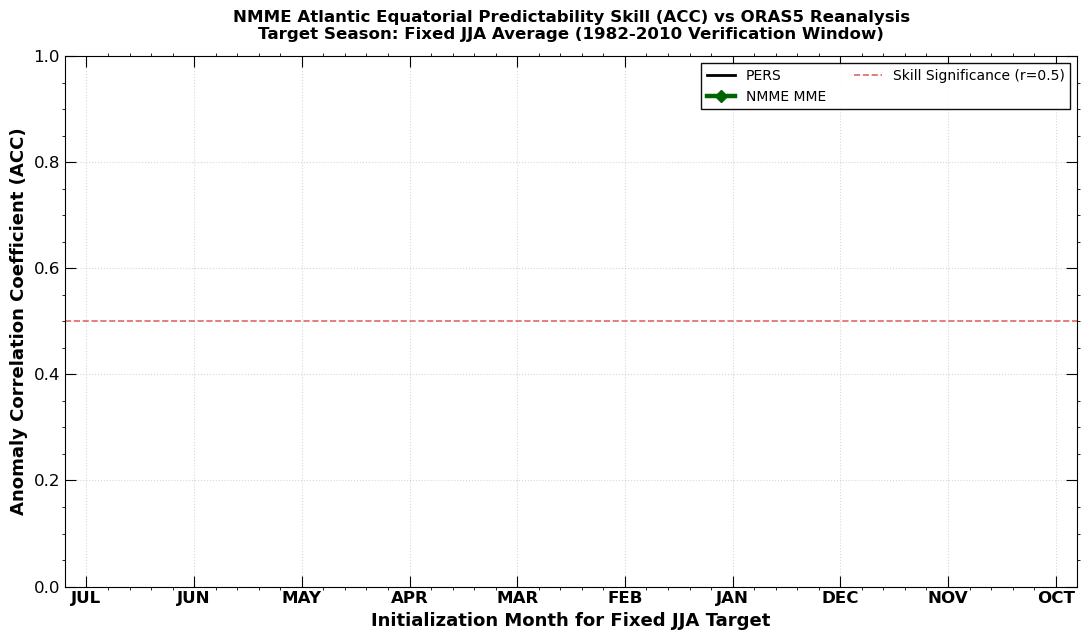

In [7]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import glob
import os
from scipy.stats import pearsonr

# =========================================================================
# 1. Load and Process ORAS5 Reanalysis as Observation Data
# =========================================================================
oras5_dir = "/Users/yongyub.kim/kimyy/Research/Postdoc/10_GFI_UiB/UiB/2026_AZM_prediction_LIM/OBS"
oras5_files = sorted(glob.glob(os.path.join(oras5_dir, "oras5_sst_atl3_*.nc")))

print("Step 1: Loading and processing annual ORAS5 regional subset files...")
obs_list = []

for file_path in oras5_files:
    # Open dataset using netcdf4 to handle both CONS and OPER file models safely
    ds = xr.open_dataset(file_path, engine='netcdf4')
    
    # 1. Spatial mean over curvilinear x and y dimensions to extract the single ATL3 index
    # Note: 'sosstsst' is the variable name for SST in ORAS5
    with np.errstate(all='ignore'):
        atl3_spatial_mean = ds['sosstsst'].mean(dim=['y', 'x'])
    
    # 2. Harmonize the time axis by forcing days to the 1st of each month
    time_values = pd.to_datetime(ds['time_counter'].values)
    time_cleaned = pd.to_datetime([f"{t.year}-{t.month:02d}-01" for t in time_values])
    
    da_annual = xr.DataArray(
        data=atl3_spatial_mean.values,
        coords={'Date': time_cleaned},
        dims=['Date']
    )
    
    obs_list.append(da_annual)
    ds.close()

# Concatenate all years into a single continuous observation timeline
da_obs_all = xr.concat(obs_list, dim='Date').sortby('Date')

# Convert to Pandas DataFrame for 100% downstream compatibility
df_obs = pd.DataFrame({
    'Date': da_obs_all['Date'].values,
    'ATL3': da_obs_all.values
})
df_obs['Year'] = df_obs['Date'].dt.year
df_obs['Month'] = df_obs['Date'].dt.month

# Compute Observation SSTA based on Climatology Baseline Period: 1991-2010
obs_clim_mask = (df_obs['Date'] >= "1991-01-01") & (df_obs['Date'] <= "2010-12-01")
obs_monthly_clim = {
    m: df_obs.loc[obs_clim_mask & (df_obs['Month'] == m), 'ATL3'].mean() 
    for m in range(1, 13)
}

# Deduct monthly climatology to get the pure SSTA index
df_obs['ATL3_SSTA'] = df_obs.apply(lambda row: row['ATL3'] - obs_monthly_clim[row['Month']], axis=1)
df_obs_indexed = df_obs.set_index('Date')

print("--- ORAS5 Observational Base Sample ---")
print(df_obs[['Date', 'ATL3', 'ATL3_SSTA']].head(12))
print("---------------------------------------\n")


# =========================================================================
# 2. Load Model Dataset & Target Filters
# =========================================================================
nc_path = "/Users/yongyub.kim/kimyy/Research/Postdoc/10_GFI_UiB/UiB/2026_AZM_prediction_LIM/NMME/NMME_ATL3_SST_weighted_all_models.nc"
ds_all = xr.open_dataset(nc_path)
ds_merged = ds_all.sel(run_type="MERGED")

# Target Specific 8 Models
target_models = [
    'CanCM4i', 'CanSIPSv2', 'CMC1-CanCM3', 'CMC2-CanCM4', 
    'GEM-NEMO', 'NASA-GEOSS2S', 'NCAR-CESM1', 'NCEP-CFSv2'
]

models = [m for m in ds_merged.model.values if m in target_models]
leads = ds_merged.L.values  

# Timing Configs
start_eval = pd.Timestamp("1982-01-01")  # Evaluation period
end_eval = pd.Timestamp("2010-12-01")    

start_clim = pd.Timestamp("1991-01-01")  # Climatology Baseline period
end_clim = pd.Timestamp("2010-12-01")    

eval_years = np.arange(1982, 2011)       # 1982-2010
model_skills = {model: [] for model in models}

# Configuration matrix for target fixed JJA sequence
init_steps = [
    ('JUL', 7, 0), ('JUN', 6, 0), ('MAY', 5, 0), ('APR', 4, 0), 
    ('MAR', 3, 0), ('FEB', 2, 0), ('JAN', 1, 0), 
    ('DEC', 12, -1), ('NOV', 11, -1), ('OCT', 10, -1)
]
init_labels = [step[0] for step in init_steps]

# Define the absolute JJA verification target from observation
obs_jja_dict = {}
for year in eval_years:
    dates_jja = [pd.Timestamp(f"{year}-06-01"), pd.Timestamp(f"{year}-07-01"), pd.Timestamp(f"{year}-08-01")]
    if all(d in df_obs_indexed.index for d in dates_jja):
        obs_jja_dict[year] = df_obs_indexed.loc[dates_jja, 'ATL3_SSTA'].mean()

target_predict_month = 6 


# =========================================================================
# 3. Compute Persistence Baseline Skill (PERS)
# =========================================================================
print("Step 3: Calculating Persistence skill for Fixed JJA target...")
persistence_skills = []

for label, month_int, yr_offset in init_steps:
    obs_predictor_list = []
    obs_target_list = []
    
    for year in eval_years:
        init_year = year + yr_offset
        init_date = pd.Timestamp(f"{init_year}-{month_int:02d}-01")
        pers_anchor_date = init_date - pd.DateOffset(months=1)
        
        if (pers_anchor_date in df_obs_indexed.index) and (year in obs_jja_dict):
            obs_predictor_list.append(df_obs_indexed.loc[pers_anchor_date, 'ATL3_SSTA'])
            obs_target_list.append(obs_jja_dict[year])
            
    if len(obs_predictor_list) > 5:
        r_val, _ = pearsonr(obs_predictor_list, obs_target_list)
        persistence_skills.append(r_val)
    else:
        persistence_skills.append(np.nan)


# =========================================================================
# 4. Compute Model Forecast Skills & Save Standardized Anomalies for Master MME
# =========================================================================
print("Step 4: Processing individual models with precise lead-dependent matching...")
mme_field_list = []

for model_name in models:
    ds_mod = ds_merged.sel(model=model_name).sortby('S')
    time_axis_raw = ds_mod['S'].values
    time_axis_S = pd.to_datetime([f"{t.year}-{t.month:02d}-01" for t in time_axis_raw])
    ds_mod = ds_mod.assign_coords(S=time_axis_S)
    
    # Isolate baseline data for model climatology
    baseline_ds = ds_mod.sel(S=slice(start_clim, end_clim))
    with np.errstate(all='ignore'):
        master_clim_field = baseline_ds['atl3_sst'].mean(dim='M').groupby('S.month').mean(dim='S', skipna=True)
    
    clim_np_matrix = master_clim_field.values  # Raw numpy shape: (12, 12)
    gfdl_ssta = ds_mod['atl3_sst'].copy(deep=True)
    
    for l_idx, lead in enumerate(leads):
        init_months_idx = ds_mod['S'].dt.month.values - 1
        mapped_clim_np = clim_np_matrix[init_months_idx, l_idx]
        
        # All-NaN column defensive override (Prevents data explosion for models like NCEP-CFSv2)
        if np.isnan(mapped_clim_np).all():
            mapped_clim_np = np.zeros_like(mapped_clim_np)
        
        for m_idx in range(len(ds_mod.M)):
            gfdl_ssta.loc[dict(L=lead, M=ds_mod.M.values[m_idx])] = \
                ds_mod['atl3_sst'].sel(L=lead, M=ds_mod.M.values[m_idx]).values - mapped_clim_np
                
    ens_mean_anom = gfdl_ssta.mean(dim='M')
    
    # Process skills across individual lead milestones
    model_step_arrays = []
    for label, month_int, yr_offset in init_steps:
        forecast_years_series = []
        
        for year in eval_years:
            init_year = year + yr_offset
            init_date = pd.Timestamp(f"{init_year}-{month_int:02d}-01")
            
            chosen_predict_month = 7 if label == 'JUL' else target_predict_month
            forecast_val = np.nan
            
            if init_date in ens_mean_anom['S'].values:
                mod_at_init = ens_mean_anom.sel(S=init_date)
                for lead_val in mod_at_init['L'].values:
                    v_month = init_date.month + int(lead_val)
                    if v_month > 12: v_month -= 12
                    if v_month == chosen_predict_month:
                        forecast_val = mod_at_init.sel(L=lead_val).values.item()
                        break
            
            forecast_years_series.append(forecast_val)
            
        # Individual model correlation with ORAS5 SSTA target
        valid_forecasts = []
        valid_targets = []
        for idx, yr in enumerate(eval_years):
            if not np.isnan(forecast_years_series[idx]) and yr in obs_jja_dict:
                valid_forecasts.append(forecast_years_series[idx])
                valid_targets.append(obs_jja_dict[yr])
                
        if len(valid_forecasts) > 5:
            r_val, _ = pearsonr(valid_forecasts, valid_targets)
            model_skills[model_name].append(r_val)
        else:
            model_skills[model_name].append(np.nan)
            
        # Save structural array for high-fidelity MME spatial matrix alignment
        model_step_arrays.append(xr.DataArray(forecast_years_series, coords=[eval_years], dims=['year']))
        
    model_mme_da = xr.concat(model_step_arrays, dim=pd.Index(init_labels, name='init_label'))
    mme_field_list.append(model_mme_da)


# =========================================================================
# 5. Compute Multi-Model Ensemble (MME) Mean Skill
# =========================================================================
print("Step 5: Synching dimensions and calculating Noise-free MME Skill vs ORAS5...")

# Consolidate all model predictions into a coherent grid matrix: (model, init_label, year)
master_mme_array = xr.concat(mme_field_list, dim=pd.Index(models, name='model'))

# Perform multi-model mean aggregation ahead of correlation calculation to cancel random drift noises
mme_forecast_field = master_mme_array.mean(dim='model', skipna=True)

mme_skills = []
for label in init_labels:
    mme_time_series = []
    obs_time_series = []
    
    for year in eval_years:
        f_val = mme_forecast_field.sel(init_label=label, year=year).values.item()
        if not np.isnan(f_val) and year in obs_jja_dict:
            mme_time_series.append(f_val)
            obs_time_series.append(obs_jja_dict[year])
            
    if len(mme_time_series) > 5:
        r_val, _ = pearsonr(mme_time_series, obs_time_series)
        mme_skills.append(r_val)
    else:
        mme_skills.append(np.nan)


# =========================================================================
# 6. Plotting the Scientific Comparison Frame
# =========================================================================
print("Step 6: Generating high-fidelity target-season predictability curves...")
fig, ax = plt.subplots(figsize=(11, 6.5))
x_indices = np.arange(len(init_labels))

# 6a. Plot Persistence Baseline
ax.plot(x_indices, persistence_skills, color='black', linewidth=2.0, linestyle='-', label='PERS', zorder=8)

# 6b. Plot Core Individual Forecast Models (Dotted and Semi-transparent for better focal contrast)
for model_name, skills in model_skills.items():
    if not np.isnan(skills).all():
        ax.plot(x_indices, skills, linewidth=1.0, alpha=0.4, linestyle=':')

# 6c. Plot the Dimension-Aligned True Multi-Model Ensemble Skill (Thick Dark Green Diamond Line)
ax.plot(x_indices, mme_skills, color='darkgreen', linewidth=3.2, linestyle='-', marker='D', markersize=6, label='NMME MME', zorder=20)

# Frame Styling Framework (NCL/Matplotlib Premium Layout)
ax.set_ylim(0.0, 1.0)
ax.set_xlim(-0.2, len(init_labels) - 0.8)
ax.set_xticks(x_indices)
ax.set_xticklabels(init_labels, fontsize=12, fontweight='bold')
ax.tick_params(axis='both', which='major', direction='in', length=8, labelsize=12)
ax.yaxis.set_ticks_position('both')
ax.xaxis.set_ticks_position('both')
ax.minorticks_on()
ax.axhline(0.5, color='tab:red', linestyle='--', linewidth=1.2, alpha=0.7, label='Skill Significance (r=0.5)')

ax.set_ylabel("Anomaly Correlation Coefficient (ACC)", fontsize=13, fontweight='bold')
ax.set_xlabel("Initialization Month for Fixed JJA Target", fontsize=13, fontweight='bold')
ax.set_title("NMME Atlantic Equatorial Predictability Skill (ACC) vs ORAS5 Reanalysis\nTarget Season: Fixed JJA Average (1982-2010 Verification Window)", fontsize=12, fontweight='bold', pad=12)
ax.legend(loc='upper right', edgecolor='black', fancybox=False, fontsize=10, framealpha=0.95, ncol=2)
ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
print("All scientific verification procedures completed successfully.")
plt.show()